# 3주차_기계학습과_인식_1

- preview
- 기계학습 기초
- 인공지능 제품의 설계와 구현
- 데이터에 대한 이해
- 특징 추출과 표현
- 필기 숫자 인식
- 성능 측정
- 인공지능은 어떻게 인식을 하나?
---

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런(sklearn)의 `datasets` 모듈을 통해 제공되는 유명한 **아이리스(iris)** 붓꽃 데이터셋을 로드하여,  
# 해당 데이터셋의 설명(descriptor)을 출력한 후, 각 데이터 샘플(입력값)과 그에 대응하는 정답 레이블(타겟값)을 순차적으로 출력하는 간단한 분석용 코드임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: sklearn에서 제공하는 iris 데이터셋을 로드
# 2단계: 데이터셋에 대한 전반적인 설명(데이터 구조, 변수 설명 등) 출력
# 3단계: 각 샘플의 입력 피처와 정답 타겟을 순서대로 출력
# ------------------------------------------------------------

from sklearn import datasets  # 사이킷런에서 데이터셋 관련 기능을 제공하는 모듈을 불러옴

d = datasets.load_iris()  # 아이리스 데이터셋을 로드하고 변수 d에 저장
# → d는 dict 형태로 구성되며, d.data, d.target, d.feature_names, d.DESCR 등의 속성을 포함함

print(d.DESCR)  # 데이터셋에 대한 전체 설명(데이터셋 개요, 변수 설명, 출처 등)을 출력
# → 데이터 구조를 이해하는 데 유용한 정보이며, 분석 전에 참고함

print("\n\n----------------------------\n\n")  # 시각적 구분을 위한 구분선 출력

for i in range(0, len(d.data)):  # 전체 데이터 샘플 수만큼 반복 수행
    print(i + 1, d.data[i], d.target[i])  
    # → i+1번째 샘플의 피처 값(d.data[i])과 해당 클래스 라벨(d.target[i])을 함께 출력
    # d.data[i]: 4개의 부리·잎·꽃잎 길이 등 피처값
    # d.target[i]: 해당 샘플이 속한 품종의 정수 ID (0: setosa, 1: versicolor, 2: virginica)


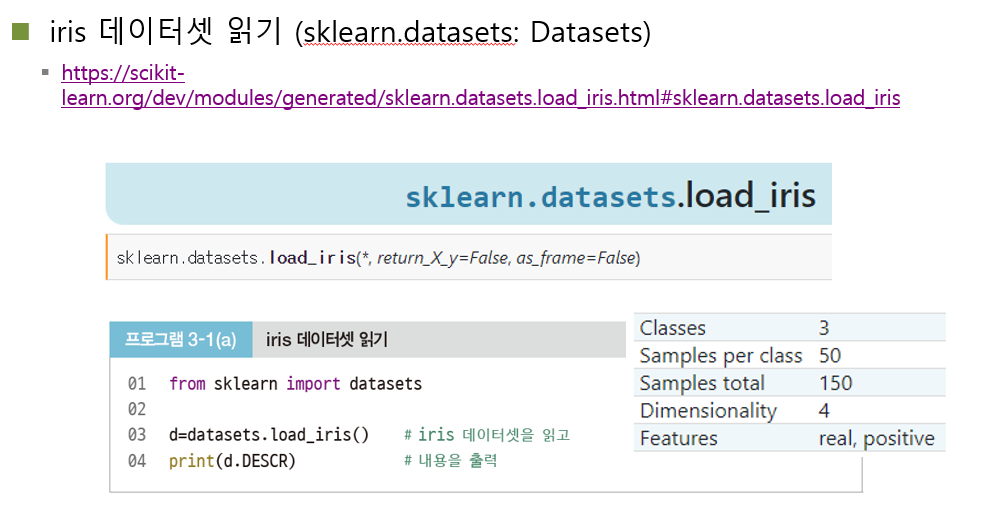

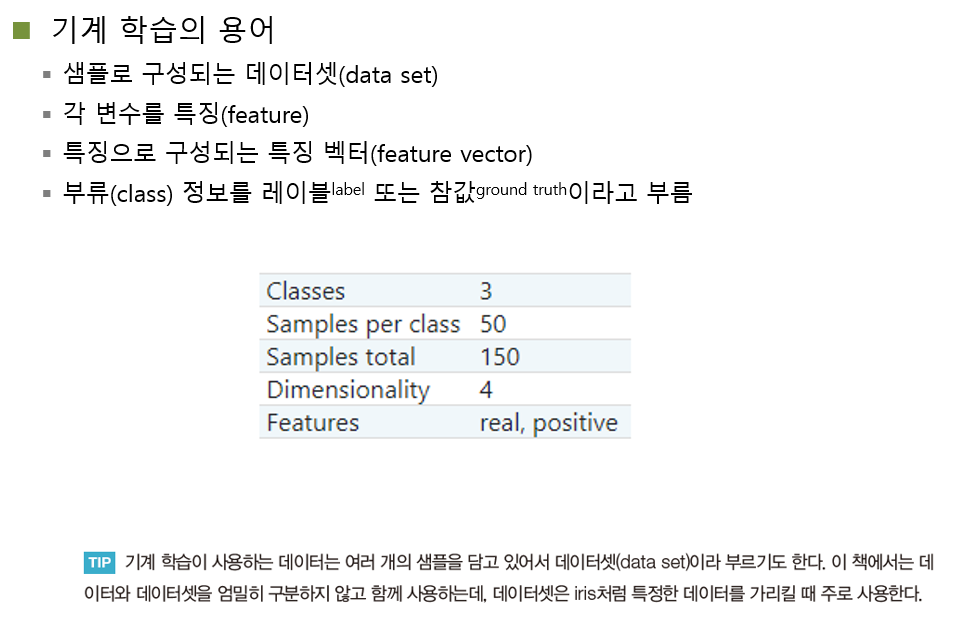

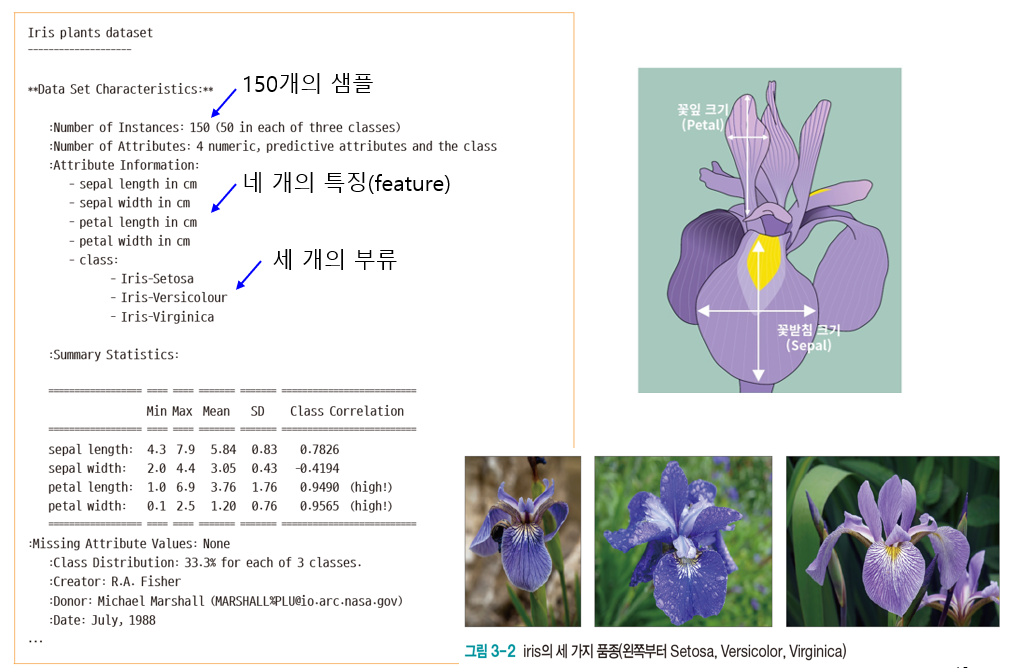

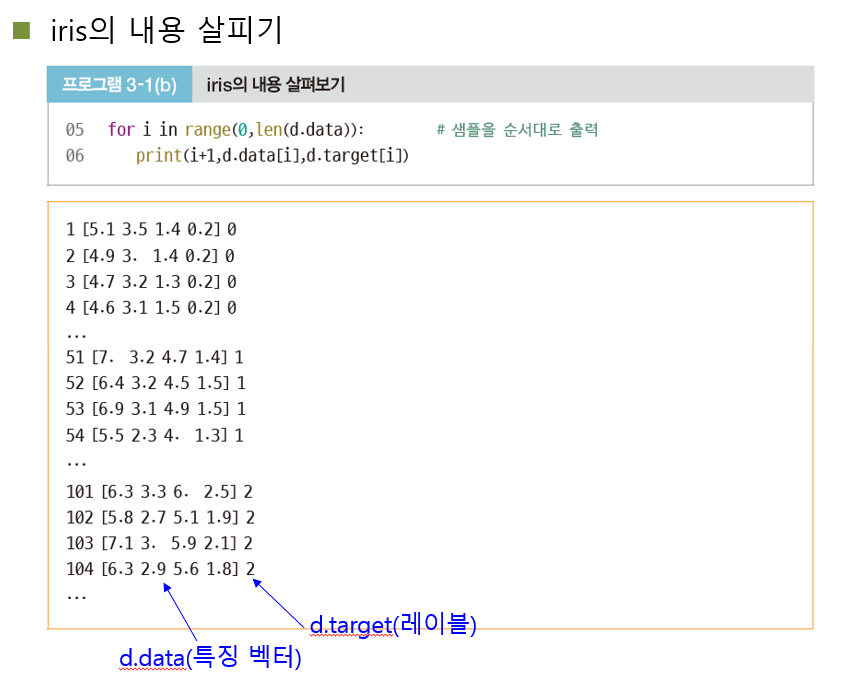

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런(sklearn)의 SVM(Support Vector Machine) 분류기를 이용하여  
# 붓꽃 데이터셋(iris dataset)에 대해 분류 모델을 학습하고,  
# 학습된 모델로 새로운 샘플 2개의 품종을 예측하는 코드임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: SVM 분류기(SVC) 객체 생성 (하이퍼파라미터 설정 포함)
# 2단계: 아이리스 데이터셋을 이용하여 분류 모델 학습
# 3단계: 새로운 입력 데이터 2개를 정의
# 4단계: 학습된 모델로부터 해당 샘플의 예측 결과 얻기
# 5단계: 예측 결과(클래스 번호)를 출력
# ------------------------------------------------------------

from sklearn import svm  # 서포트 벡터 머신(SVM) 관련 클래스를 포함한 모듈을 임포트

# SVM 분류기 객체(SVC)를 생성
s = svm.SVC(gamma=0.1, C=10)  
# gamma: RBF 커널에서의 감쇠 정도 (작을수록 넓은 영향력), C: 오차 허용 범위 (클수록 복잡한 모델 허용)

# 앞서 불러온 iris 데이터셋으로 모델 학습 수행
s.fit(d.data, d.target)  
# d.data: 150개의 샘플 (입력값), d.target: 각 샘플의 정답 레이블

# 새로운 입력 데이터 정의
new_d = [
    [6.4, 3.2, 6.0, 2.5],   # 기존 iris 샘플을 약간 변형한 형태
    [7.1, 3.1, 4.7, 1.35],  # 입력 피처는 꽃받침 길이/너비, 꽃잎 길이/너비 순서
]

# 학습된 모델로 새로운 입력에 대한 클래스 예측 수행
res = s.predict(new_d)  
# 반환값 res는 각 샘플이 예측된 클래스 번호(0, 1, 2 중 하나)를 담은 리스트

# 예측 결과 출력
print("새로운 2개 샘플의 부류는", res)  
# 예: [2 1] → 첫 번째 샘플은 virginica, 두 번째 샘플은 versicolor로 예측되었다는 의미


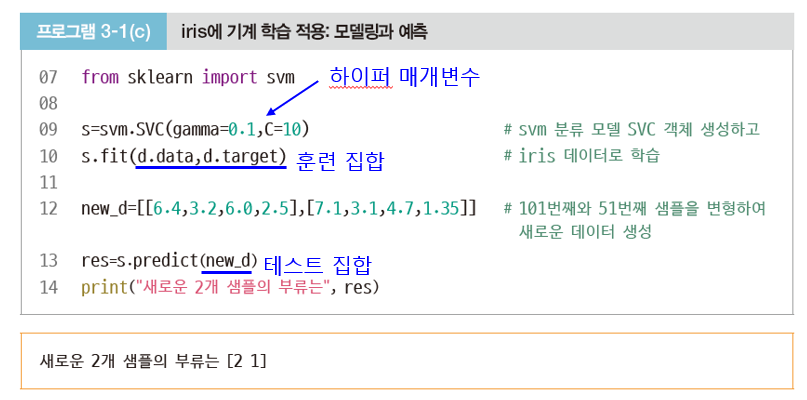

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 Plotly 라이브러리의 `express` 모듈을 활용하여  
# 아이리스(iris) 데이터셋을 3차원 공간 상에서 시각화하는 예제임.  
# 시각화된 결과는 각 샘플의 꽃잎/꽃받침 특성에 따라 다른 품종 간의 군집 구조를 직관적으로 파악하는 데 목적이 있음.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: Plotly에서 제공하는 아이리스 데이터를 불러옴
# 2단계: 3개의 피처(sepal_length, sepal_width, petal_width)를 기준으로 3D 산점도 생성
# 3단계: 데이터의 품종(species)을 색상으로 구분하여 시각화
# 4단계: 렌더러를 "browser"로 설정하여 외부 브라우저에서 그래프 표시
# ------------------------------------------------------------

import plotly.express as px  # 인터랙티브 시각화를 위한 Plotly Express 모듈을 임포트

df = px.data.iris()  
# Plotly가 제공하는 내장 iris 데이터셋을 로드
# → pandas DataFrame 형식이며, 150개 샘플 × 5개 컬럼 포함
# 컬럼 예: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

# 3차원 산점도(fig)를 생성
fig = px.scatter_3d(
    df,  # 데이터프레임 전체 사용
    x='sepal_length',  # x축으로 사용할 피처 지정
    y='sepal_width',   # y축으로 사용할 피처 지정
    z='petal_width',   # z축으로 사용할 피처 지정
    color='species'    # 점 색상을 품종(species)에 따라 다르게 지정
)
# petal_length 피처는 일부러 제외하여 3차원 공간 내 분리 가능성을 확인함

fig.show(renderer="browser")  
# 생성된 인터랙티브 3D 그래프를 외부 웹 브라우저에서 표시
# renderer="browser" 설정은 Jupyter 환경이 아닌 일반 Python 환경에서도 사용 가능하게 하기 위함


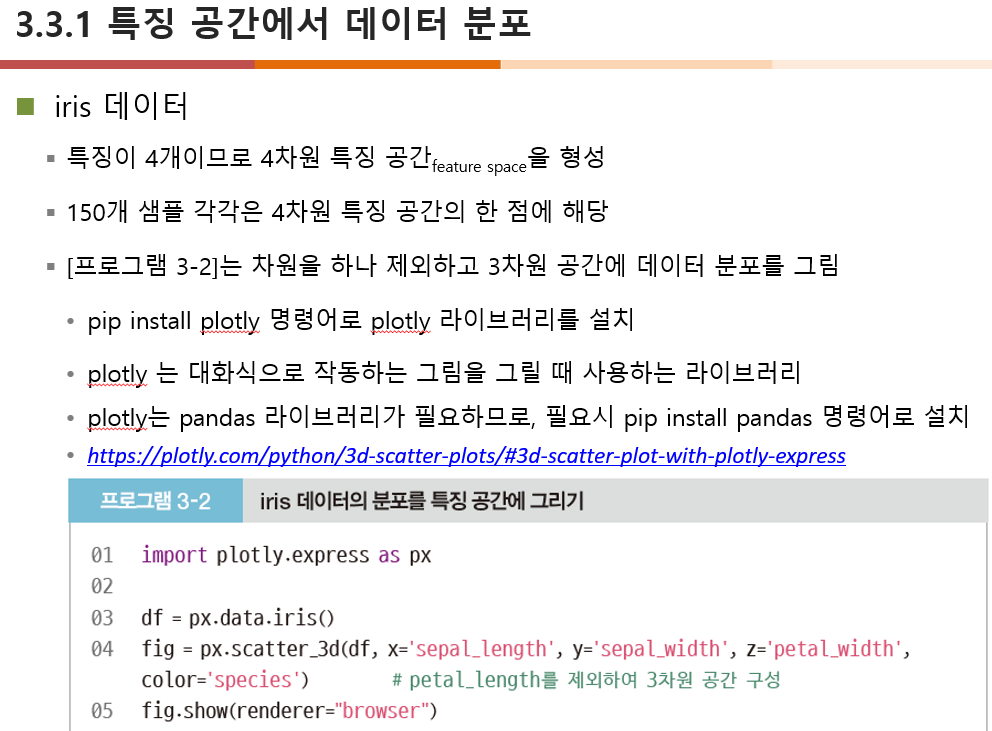

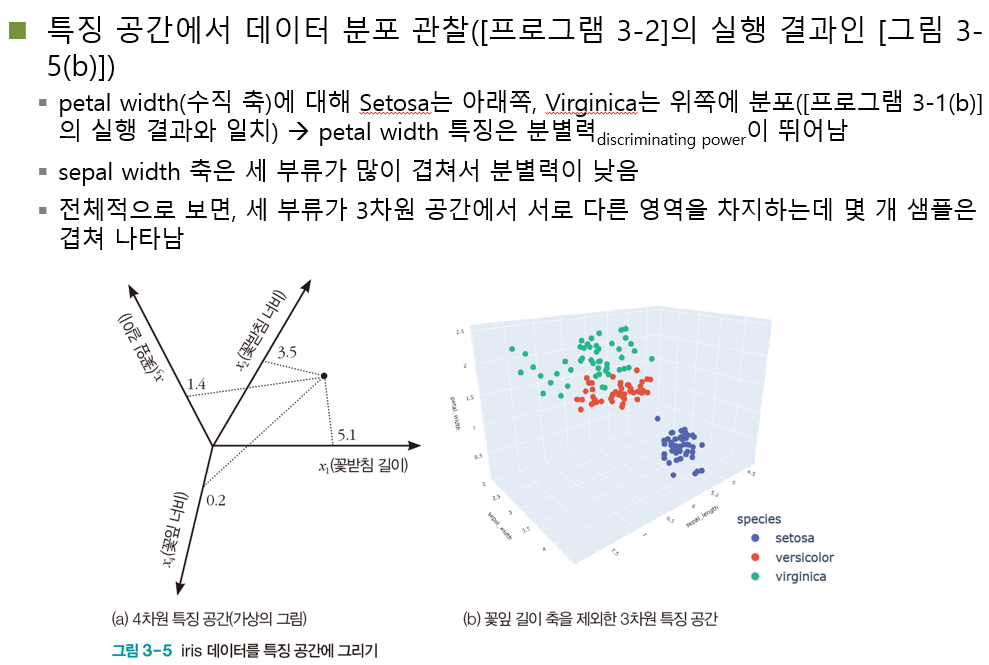

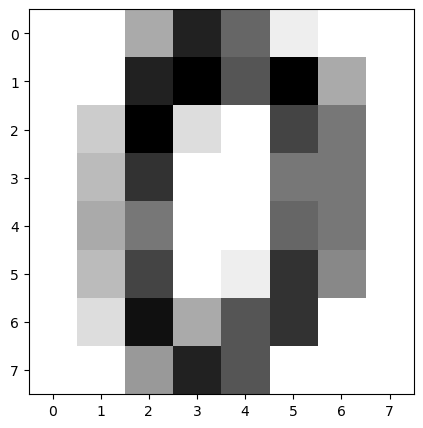

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
이 숫자는  0 입니다.


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런(sklearn)에서 제공하는 손글씨 숫자 이미지 데이터셋인 **digits**를 불러온 뒤,  
# 첫 번째 샘플의 이미지를 시각화하고 해당 샘플의 실제 픽셀값 및 라벨(정답 숫자)을 출력하는 예제임.  
# 이 데이터는 주로 분류기 모델 학습 및 이미지 인식 실습에 활용됨.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: sklearn에서 digits 데이터셋 로드
# 2단계: 첫 번째 샘플의 이미지 데이터를 시각적으로 출력
# 3단계: 해당 샘플의 원본 데이터(64차원 벡터)와 라벨을 함께 출력
# ------------------------------------------------------------

from sklearn import datasets  # 사이킷런의 데이터셋 관련 모듈을 임포트
import matplotlib.pyplot as plt  # 시각화를 위한 matplotlib의 pyplot 모듈을 임포트

digit = datasets.load_digits()  
# sklearn의 digits 손글씨 숫자 데이터셋을 로드하고 변수 digit에 저장
# digit은 이미지(8x8 배열), 벡터화된 데이터, 레이블 등을 포함한 딕셔너리 형태

plt.figure(figsize=(5, 5))  
# 이미지 출력을 위한 그림(canvas) 공간을 생성하며, 출력 크기를 지정

plt.imshow(
    digit.images[0], cmap=plt.cm.gray_r, interpolation="nearest"
)  
# 0번째 샘플의 8x8 이미지 배열을 시각화
# cmap=plt.cm.gray_r: 흑백 반전(밝은 숫자가 진하게 표시됨)
# interpolation="nearest": 픽셀 경계가 선명하게 출력되도록 설정

plt.show()  
# 위에서 설정한 이미지를 실제로 화면에 표시

print(digit.data[0])  
# 0번째 샘플의 픽셀값 64개를 1차원 벡터 형태로 출력 (8x8 이미지를 일렬로 나열한 형태)
# 각 값은 0~16 사이의 밝기값을 의미함

print("이 숫자는 ", digit.target[0], "입니다.")  
# 0번째 샘플의 실제 라벨(정답 숫자)을 출력
# 예: "이 숫자는 0 입니다." → 이 이미지는 숫자 '0'을 나타냄


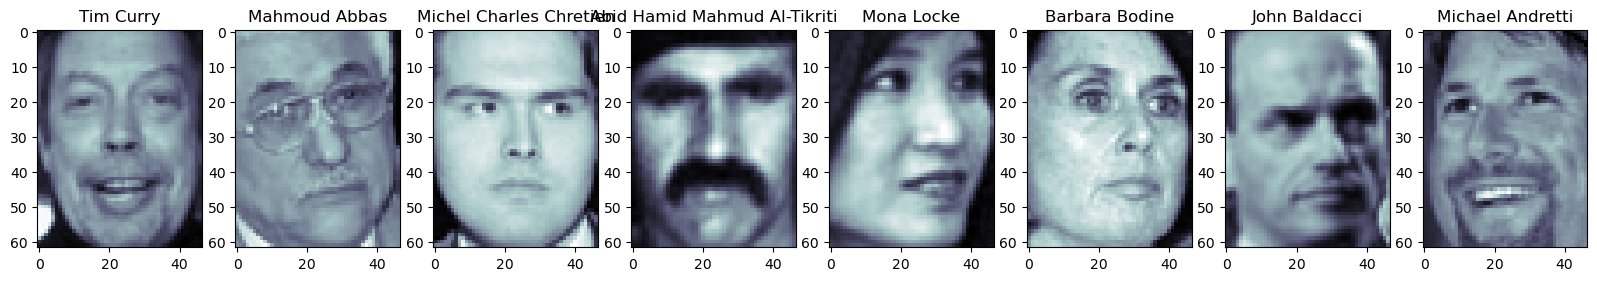

*****
 From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----




 
*****
이 문서의 부류는 < rec.autos > 입니다.


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런에서 제공하는 두 가지 유명한 데이터셋을 활용하여 시각화 및 텍스트 분석을 수행함:
# ① LFW(Labeled Faces in the Wild): 유명인 얼굴 이미지 데이터셋 → 이미지 시각화
# ② 20 Newsgroups: 뉴스 기사 텍스트 데이터셋 → 텍스트와 부류 출력
#
# 각 데이터셋은 머신러닝의 전처리, 분류기 학습, 시각화 등에 자주 사용되며,
# 얼굴 인식 및 텍스트 분류 모델 개발을 위한 기본 예제 자료로 활용됨.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: LFW 얼굴 이미지 데이터셋 로드 및 일부 이미지 시각화
# 2단계: 각 얼굴의 실명(타깃 이름)을 라벨로 출력
# 3단계: 20개의 뉴스그룹 텍스트 데이터셋 로드
# 4단계: 첫 번째 뉴스 문서의 원본 텍스트 출력
# 5단계: 해당 문서가 속한 뉴스 부류명을 함께 출력
# ------------------------------------------------------------

from sklearn.datasets import fetch_lfw_people  # 얼굴 이미지 데이터셋을 로드하기 위한 함수 임포트
import matplotlib.pyplot as plt  # 이미지 시각화를 위한 matplotlib 모듈 임포트
from sklearn import datasets  # 텍스트 데이터셋 로드를 위한 사이킷런 데이터셋 모듈 임포트

lfw = fetch_lfw_people()  
# LFW(Labeled Faces in the Wild) 얼굴 이미지 데이터셋을 로드
# lfw.images → 이미지 배열 (n_samples, height, width)
# lfw.target → 각 이미지의 클래스 인덱스
# lfw.target_names → 클래스 인덱스에 대응하는 사람 이름 목록

plt.figure(figsize=(20, 5))  
# 전체 그림 영역을 가로 20인치 × 세로 5인치로 설정하여 시각화 크기 조정

for i in range(8):  # 처음 8개의 얼굴 이미지를 반복하여 출력
    plt.subplot(1, 8, i + 1)  # 한 줄에 8개의 subplot을 배치하며 현재 위치를 지정
    plt.imshow(lfw.images[i], cmap=plt.cm.bone)  # i번째 얼굴 이미지를 흑백 톤(cmap='bone')으로 시각화
    plt.title(lfw.target_names[lfw.target[i]])  # 해당 이미지의 인물 이름(타겟 라벨)을 제목으로 표시

plt.show()  # 시각화된 이미지들을 출력

# ------------------------------------------------------------
# 뉴스 기사 텍스트 데이터셋 (20 Newsgroups) 로드 및 출력
# ------------------------------------------------------------

news = datasets.fetch_20newsgroups(subset="train")  
# 20 Newsgroups 텍스트 데이터셋을 훈련용(subset='train')으로 로드
# news.data: 실제 뉴스 기사 원문 리스트 (문자열 형태)
# news.target: 각 문서가 속한 부류의 인덱스
# news.target_names: 인덱스에 대응되는 뉴스그룹 부류 이름

print("*****\n", news.data[0], "\n*****")  
# 첫 번째 뉴스 문서(news.data[0])의 본문을 출력

print("이 문서의 부류는 <", news.target_names[news.target[0]], "> 입니다.")  
# 첫 번째 뉴스 문서가 속한 부류명을 출력
# 예: "<comp.graphics>" 또는 "<soc.religion.christian>" 등


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 sklearn의 손글씨 숫자 데이터셋 `digits`를 불러와,
# SVM(Support Vector Machine) 분류기를 학습시킨 후,  
# 일부 샘플에 대한 예측을 수행하고, 전체 훈련 데이터를 대상으로 정확률을 계산하는 실습 코드임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: digits 데이터셋 로드 (8x8 손글씨 숫자 이미지)
# 2단계: SVM 분류기(SVC) 생성 및 훈련 데이터로 모델 학습
# 3단계: 앞의 3개 샘플을 테스트 입력으로 사용하여 예측 수행
# 4단계: 예측 결과와 실제 정답 비교
# 5단계: 전체 훈련 데이터를 테스트로 간주하여 정확률 계산
# ------------------------------------------------------------

from sklearn import datasets  # 사이킷런 데이터셋 관련 모듈 임포트
from sklearn import svm  # 서포트 벡터 머신(SVM) 알고리즘 관련 모듈 임포트

digit = datasets.load_digits()  
# 손글씨 숫자 이미지 데이터셋(digits)을 로드
# digit.data → (n_samples, 64) 크기의 평탄화된 픽셀 데이터
# digit.target → 각 샘플의 정답(숫자 라벨) 0~9

# SVM 분류기 객체를 생성하며, 하이퍼파라미터 설정
s = svm.SVC(gamma=0.1, C=10)  
# gamma: RBF 커널에서의 감쇠 정도 설정
# C: 오차 허용 범위 설정 (클수록 복잡한 모델 허용)

# digit 데이터 전체를 사용하여 분류기 학습
s.fit(digit.data, digit.target)  
# 입력: 64차원의 이미지 벡터, 출력: 정답 라벨 (0~9)

# 앞쪽 3개 샘플을 테스트용 입력 데이터로 간주하고 예측 수행
new_d = [digit.data[0], digit.data[1], digit.data[2]]  
# 실제로는 훈련 데이터이지만, 여기서는 새 입력처럼 사용

res = s.predict(new_d)  
# 모델에 new_d를 입력하여 예측된 클래스(숫자)를 반환받음

print("예측값은", res)  
# 예측된 결과(숫자 3개)를 출력

print("참값은", digit.target[0], digit.target[1], digit.target[2])  
# 예측값과 비교하기 위한 실제 정답을 출력

# 훈련 데이터를 테스트셋으로 간주하여 전체 데이터에 대해 예측 수행
res = s.predict(digit.data)  
# 전체 1797개 샘플에 대해 예측 수행

# 예측값과 실제 정답이 일치한 인덱스를 수집
correct = [i for i in range(len(res)) if res[i] == digit.target[i]]  
# 정답을 맞춘 경우의 인덱스를 리스트로 저장

accuracy = len(correct) / len(res)  
# 정확률 계산: 맞춘 개수 / 전체 개수

print("화소 특징을 사용했을 때 정확률=", accuracy * 100, "%")  
# 최종 정확률(%)을 출력


예측값은 [0 1 2]
참값은 0 1 2
화소 특징을 사용했을 때 정확률= 100.0 %


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 sklearn의 `digits` 손글씨 숫자 데이터셋을 사용하여  
# SVM(Support Vector Machine) 분류기를 훈련하고, 테스트 데이터셋에 대한 예측 결과를  
# **혼동 행렬(confusion matrix)**을 이용해 평가한 후, 정확률을 계산하는 실습 코드임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 손글씨 데이터셋 로드 및 학습/테스트 분할
# 2단계: SVM 모델 학습 수행
# 3단계: 테스트셋 예측 수행
# 4단계: 예측 결과와 실제 정답을 바탕으로 혼동 행렬 생성
# 5단계: 혼동 행렬을 기반으로 전체 정확률 계산
# ------------------------------------------------------------

from sklearn import datasets  # 사이킷런의 데이터셋 모듈 임포트
from sklearn import svm  # SVM 분류기를 위한 모듈 임포트
from sklearn.model_selection import train_test_split  # 데이터셋 분할을 위한 함수 임포트
import numpy as np  # 수치 연산 및 행렬 처리를 위한 numpy 모듈 임포트

# ------------------------------------------------------------
# [1단계] 데이터 로드 및 분할
# ------------------------------------------------------------

digit = datasets.load_digits()  
# digits 데이터셋 로드 (1797개의 손글씨 숫자 이미지 포함)

x_train, x_test, y_train, y_test = train_test_split(
    digit.data, digit.target, train_size=0.6
)  
# 전체 데이터셋을 훈련용 60%, 테스트용 40%로 분할
# x_train/x_test: 각 샘플의 화소 정보 (64차원 벡터)
# y_train/y_test: 해당 샘플의 실제 숫자 라벨 (0~9)

# ------------------------------------------------------------
# [2단계] SVM 분류기 학습
# ------------------------------------------------------------

s = svm.SVC(gamma=0.001)  
# SVM 분류기 객체 생성 (gamma는 RBF 커널의 반경 조절 파라미터)

s.fit(x_train, y_train)  
# 훈련 데이터로 SVM 분류기 학습 수행

res = s.predict(x_test)  
# 테스트 데이터셋에 대해 예측 결과(res) 생성

# ------------------------------------------------------------
# [3단계] 혼동 행렬 생성
# ------------------------------------------------------------

conf = np.zeros((10, 10))  
# 10×10 크기의 혼동 행렬(confusion matrix) 초기화
# conf[i][j]는 실제 클래스 j인데 예측을 i로 한 횟수를 의미

for i in range(len(res)):  
    conf[res[i]][y_test[i]] += 1  
    # 예측 결과 res[i], 실제 정답 y_test[i]에 따라 해당 셀 값을 증가시킴

print(conf)  
# 완성된 혼동 행렬을 출력

# ------------------------------------------------------------
# [4단계] 정확률 계산
# ------------------------------------------------------------

no_correct = 0  # 정확히 예측한 샘플 수 저장용 변수 초기화
for i in range(10):  
    no_correct += conf[i][i]  
    # 대각선(conf[i][i])은 정답을 정확히 맞춘 경우의 수

accuracy = no_correct / len(res)  
# 전체 테스트 샘플 수 대비 정확히 맞춘 비율을 정확률로 계산

print("테스트 집합에 대한 정확률은", accuracy * 100, "%입니다.")  
# 정확률을 퍼센트(%)로 출력


[[75.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 70.  0.  0.  0.  0.  1.  0.  2.  0.]
 [ 0.  0. 66.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. 66.  0.  0.  0.  0.  0.  1.]
 [ 0.  0.  0.  0. 77.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. 63.  0.  0.  0.  2.]
 [ 0.  0.  0.  0.  0.  0. 66.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0. 75.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 69.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 85.]]
테스트 집합에 대한 정확률은 99.02642559109874 %입니다.


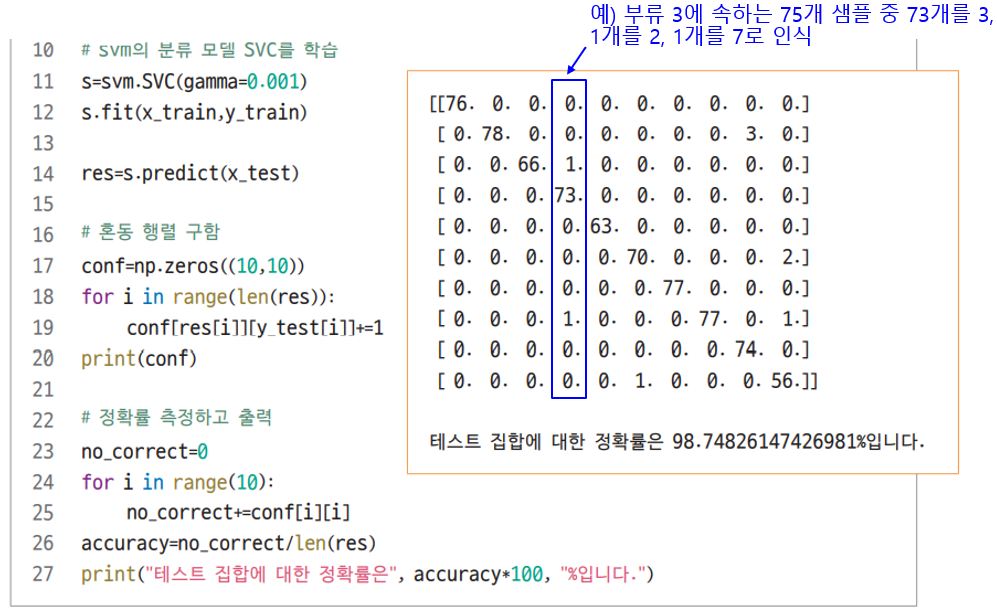

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런의 `digits` 손글씨 숫자 데이터셋을 대상으로,
# SVM(Support Vector Machine) 분류기를 이용하여 **5-겹 교차 검증(Cross-Validation)**을 수행하고,
# 각 fold의 정확률, 평균 정확률, 표준편차를 출력하는 실습 코드임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: digits 데이터셋 로드
# 2단계: SVM 모델 객체 생성
# 3단계: cross_val_score를 통해 5-겹 교차 검증 수행
# 4단계: 각 fold의 정확률, 평균 정확률 및 표준편차 출력
# ------------------------------------------------------------

from sklearn import datasets  # 사이킷런의 데이터셋 로딩 모듈 임포트
from sklearn import svm  # SVM 분류기 모델을 위한 모듈 임포트
from sklearn.model_selection import cross_val_score  # 교차 검증 수행을 위한 함수 임포트
import numpy as np  # 수치 연산 및 통계 처리를 위한 numpy 모듈 임포트

digit = datasets.load_digits()  
# sklearn의 digits 손글씨 숫자 이미지 데이터셋을 로드
# digit.data → (n_samples, 64) 형태의 입력 벡터 (8x8 이미지 평탄화)
# digit.target → 각 샘플의 실제 정답 라벨 (0~9)

s = svm.SVC(gamma=0.001)  
# SVM 분류기 객체 생성 (커널은 기본값 'rbf', 감쇠 계수 gamma=0.001 지정)
# gamma가 작을수록 결정 경계가 부드러워짐

accuracies = cross_val_score(s, digit.data, digit.target, cv=5)  
# 교차 검증 수행: 전체 데이터를 5개의 fold로 나누어 학습/검증을 반복
# 반환값은 fold 수만큼의 정확률 리스트 (예: [0.98, 0.97, 0.96, 0.99, 0.98])

print(accuracies)  
# 각 fold에서 측정된 정확률들을 배열 형태로 출력

print(
    "정확률(평균)=%0.3f, 표준편차 =%0.3f" % (accuracies.mean() * 100, accuracies.std())
)  
# 평균 정확률을 백분율(%)로 출력하고, fold 간 정확률 분산 정도를 표준편차로 표시


[0.975      0.95       0.98328691 0.99164345 0.96100279]
정확률(평균)=97.219, 표준편차 =0.015


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런(sklearn)의 SVC(Support Vector Classifier)를 활용하여  
# 아이리스(iris) 데이터셋을 분류하는 기본적인 SVM 모델을 학습하고,  
# 테스트 데이터에 대한 예측 정확도를 평가하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 데이터셋 로드 및 학습/테스트 세트 분할
# 2단계: 기본 설정의 SVC 모델 생성
# 3단계: 훈련 데이터로 모델 학습
# 4단계: 테스트 데이터 예측 수행
# 5단계: 정확도 평가 및 출력
# ------------------------------------------------------------

from sklearn.svm import SVC  # SVM 분류기 모델 클래스(SVC) 임포트
from sklearn.datasets import load_iris  # 아이리스 데이터셋 로드 함수 임포트
from sklearn.model_selection import train_test_split  # 데이터 분할 함수 임포트

# ------------------------------------------------------------
# [1단계] 데이터 로드 및 분할
# ------------------------------------------------------------

iris = load_iris()  
# sklearn에서 제공하는 붓꽃(iris) 데이터셋 로드
# iris.data: 입력값 (꽃받침/꽃잎 길이 등), iris.target: 품종 정답 (0, 1, 2)

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42
)  
# 데이터셋을 학습용 70%, 테스트용 30%로 분할
# random_state 설정으로 분할 결과를 고정

# ------------------------------------------------------------
# [2단계] SVM 모델 생성
# ------------------------------------------------------------

clf = SVC(C=1.0, kernel='rbf', gamma='scale')  
# SVM 분류기 객체 생성
# C: 정규화 파라미터 (오차 허용 범위, 클수록 복잡한 모델)
# kernel='rbf': 비선형 결정 경계를 위한 RBF 커널 사용
# gamma='scale': gamma 자동 설정 (1 / (n_features * X.var()))

# ------------------------------------------------------------
# [3단계] 모델 학습
# ------------------------------------------------------------

clf.fit(X_train, y_train)  
# 훈련 데이터를 사용하여 SVM 분류기 모델 학습 수행

# ------------------------------------------------------------
# [4단계] 테스트 데이터 예측
# ------------------------------------------------------------

y_pred = clf.predict(X_test)  
# 학습된 모델을 사용하여 테스트 입력에 대한 품종 예측 수행

# ------------------------------------------------------------
# [5단계] 예측 성능 평가
# ------------------------------------------------------------

from sklearn.metrics import accuracy_score  # 정확도 계산 함수 임포트

print("Accuracy:", accuracy_score(y_test, y_pred))  
# 테스트 데이터에 대한 실제 라벨(y_test)과 예측 결과(y_pred)를 비교하여 정확도를 출력


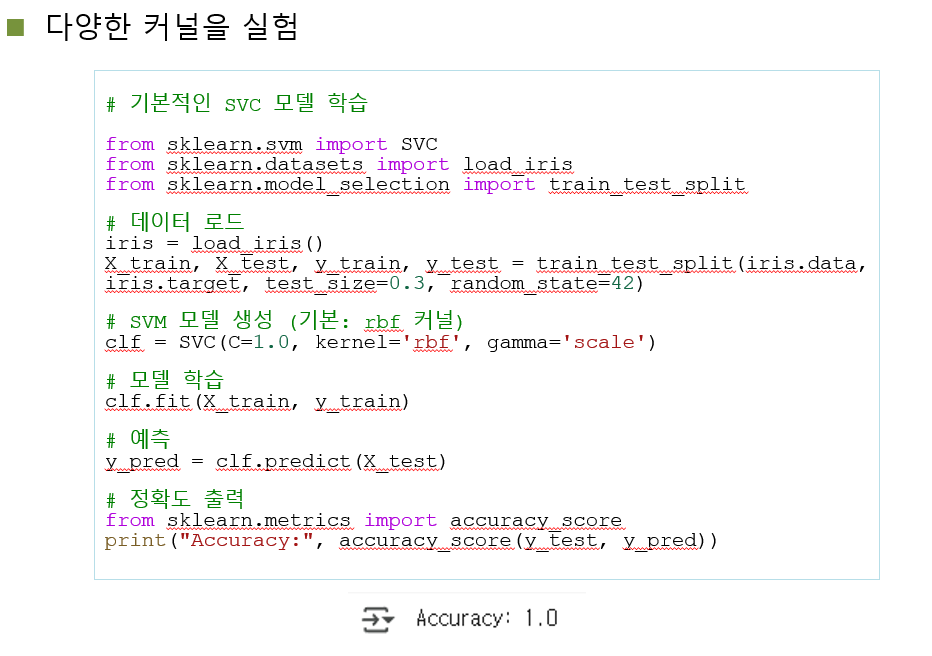

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 Support Vector Machine(SVM)의 `SVC` 모델에서  
# 다양한 커널 함수(`linear`, `poly`, `rbf`, `sigmoid`)를 사용하여  
# 각각의 커널이 분류 정확도에 어떤 영향을 미치는지 비교 실험하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 사용할 커널 함수 리스트 정의
# 2단계: 각 커널에 대해 SVM 모델 학습 및 테스트
# 3단계: 각 커널의 테스트 정확도 출력
# ------------------------------------------------------------

kernels = ['linear', 'poly', 'rbf', 'sigmoid']  
# 실험에 사용할 SVM 커널 종류를 리스트로 정의
# linear: 선형 결정 경계
# poly: 다항식 커널
# rbf: 가우시안 기반의 비선형 커널 (기본값)
# sigmoid: 시그모이드 함수 기반 커널 (신경망 유사)

for kernel in kernels:  
    # 커널 종류를 하나씩 선택하여 반복 실행

    clf = SVC(kernel=kernel)  
    # 선택된 커널을 사용하여 SVM 분류기 객체를 생성
    # 다른 하이퍼파라미터(C, gamma 등)는 기본값 사용

    clf.fit(X_train, y_train)  
    # 훈련 데이터를 사용하여 모델을 학습

    print(f"Kernel: {kernel}, Accuracy: {clf.score(X_test, y_test):.4f}")  
    # 테스트 데이터를 사용하여 모델의 정확도를 계산하고 커널 이름과 함께 출력
    # clf.score(): 내부적으로 accuracy_score()를 호출함

# 커널은 데이터를 더 높은 차원으로 옮겨서 선형 분리가 가능하게 만들어 줌.

# 2차원에서 원형으로 섞여 있던 데이터를
# 3차원으로 올려서 평면으로 분리할 수 있게 만드는 방식.

# 이를 커널 트릭(kernel trick)이라고 함.
# 데이터를 실제로 고차원으로 변환하지 않고도, 수학적으로 고차원 내적(inner product) 결과를 계산.


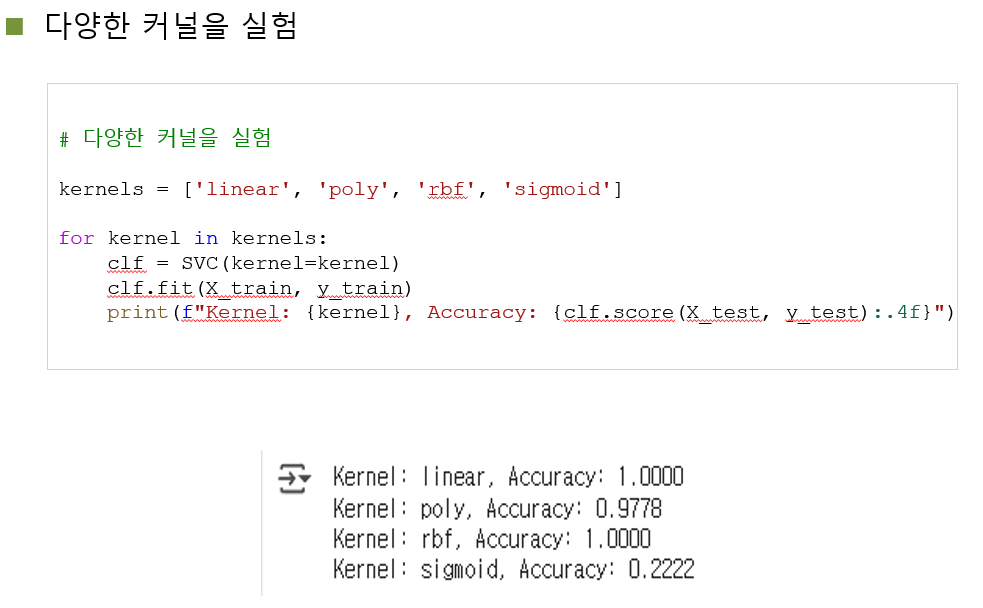